Made by: Miguel Jafert Serrano Mantilla

01/10/2022

Universidad Industrial de Santander

## Pseudo-spectral method

Lets analize the case of the Helmholtz equation:

$\nabla^2 V(x,y) + \lambda^2 V(x,y) = f(x,y)$

With given boundary conditions:

$V(x_L,y) = g_1(y) \;\;\&\;\; V(x_R,y) = g_2(y)$

$V(x,y_D) = h_1(x) \;\;\&\;\; V(x,y_T) = h_2(x)$

The following process is completly analogous to the 1D case, thus our solution function is going to be approximated with our scoring functions $\{\phi_0(x),...,\phi_N(x)\}$, $\{\phi_0(y),...,\phi_N(y)\}$:

$V(x,y) = \sum_{n,m=0}^{\infty}C_{nm}\phi_n(x)\phi_m(y)$

Our solution fuction is going to be evaluated in some colocation dots, thus our PDE becomes:

$\sum_{n,m=0}^N \left[\frac{d^2}{dx^2}\phi_n(x_i)\phi_m(y_j) + \phi_n(x_i)\frac{d^2}{dy^2}\phi_m(y_j) + \lambda^2\phi_n(x_i)\phi_m(y_j)\right]C_{nm} = f(x_i,y_j)$

This equation is a bit more bad looking that the 1D case, because we've got a tensor in the summad, so our problem becomes:

$\overleftrightarrow{T}\cdot\hat{C} = \hat{f}$

Where:

$T^{ij}_{nm} = \frac{d^2}{dx^2}\phi_n(x_i)\phi_m(y_j) + \phi_n(x_i)\frac{d^2}{dy^2}\phi_m(y_j) + \lambda^2\phi_n(x_i)\phi_m(y_j)$

And set the following tensor to put inside the boundary conditions:

$G^{ij}_{nm} = \phi_n(x_i)\phi_m(y_j)$

And $\hat{C}$ is our coefficients matrix, we must find the inverse tensor, but, that is a really hard problem even if you don't know how to operate with tensor, even these that are of fourth order, to solve this we're gonna use isomorphism between spaces. Before we "simplify" our tensor, lets look a couple of examples:

- $P_n(x) = \{a_0 , a_1x , a_2x^2 , ... , a_nx^2\}$ this is a really famous vectorial space, also known as the space made by the polyniamls of nth grade, if we want to do vectorial operations such as verify linear independence, usually is bit hard to operate with this, so what we do is to use isomorphism between $P_n$ and $\mathbb{R}^{n+1}$ traslating a vector like: $\vec{v} = 5x^2 + 2.5x^4$ to : $\vec{v} = [0,0,5,0,2.5] $.

- $M_{nxm} = 
\begin{bmatrix}
    a_{11} & a_{12} & ... & a_{1m} \\
    ... & ... & ... & ... \\
    a_{n1} & a_{n2} & ... & a_{nm}
\end{bmatrix}$ This is the vectorial space made by the matrix of dimensión $nxm$, to work with this vectorial space we can simplify it a bit more using the same logic as before, the $M_{nxm}$ space is isomorphic with the $\mathbb{R}^{nxm}$ space thus let $\{\vec{v} \in M_{2x2} :\vec{v} = \begin{bmatrix} 
a & b \\
c & d 
\end{bmatrix} \}$ then this vector can be represent as: $\vec{v} = [a,b,c,d] \;\;:\; \vec{v} \in \mathbb{R}^4$.

Thus our task is to translate the tensor $\overleftrightarrow{T}$ to a matrix $\hat{M}$ this is really hard to imagine physically because a fourth order tensor scapes out from our 3D space we can do it mathematically, so our matrix $\hat{M}$ becomes:

$\begin{bmatrix}
    G^{00}_{00} & G^{00}_{01} & ... & G^{00}_{0N} & G^{00}_{10}& ... &G^{00}_{1N} & ... & G^{0N}_{00} & ... & G^{0N}_{NN}\\
    T^{10}_{00} & T^{10}_{01} & ... & T^{10}_{0N} & T^{10}_{10}& ... &T^{10}_{1N} & ... & T^{1N}_{00} & ... & T^{1N}_{NN} \\
    ... & ... & ... & ... & ... & ... & ... & ... & ... & ... & ...\\
    T^{(N-1)0}_{00} & T^{(N-1)0}_{01} & ... & T^{(N-1)0}_{0N} & T^{(N-1)0}_{10}& ... &T^{(N-1)0}_{1N} & ... & T^{(N-1)N}_{00} & ... & T^{(N-1)N}_{NN} \\
    G^{N0}_{00} & G^{N0}_{01} & ... & G^{N0}_{0N} & G^{N0}_{10}& ... &G^{N0}_{1N} & ... & G^{NN}_{00} & ... & G^{NN}_{NN}
\end{bmatrix}_{(N+1)^2 x (N+1)^2}$

And now, we're gonna translate our coefficients matrix $\hat{C}$ to this vector:

$C = \begin{bmatrix}
    C_{00}\\
    C_{01}\\
    C_{02}\\
    ...\\
    C_{NN}
\end{bmatrix}_{(N+1)^2}$

Now,we must translate the source vector but we must be really carefull with the boundary conditions in this vector thus:

$f = \begin{bmatrix}
    g_1(y_0) \\
    g_1(y_1) \\
    g_1(y_N) \\
    h_1(x_0) \\
    f(x_1,y_1)\\
    f(x_1,y_{N-1}\\
    h_2(x_1)\\
    ...\\
    f(x_{N-1},y_{N-1})\\
    h_2(x_{N-1})\\
    ...\\
    g_2(y_0)\\
    ...\\
    g_2(y_N)\\
\end{bmatrix}_{(N+1)^2}$

With all of this, our problem becomes one of matrix inversion, lets analize one example.

## Example 1: $\nabla^2 V(x,y) = sin(\pi x)sin(\pi y)$

with homogeneous Dirichlet boundary conditions such that:

$V(-1,y) = V(1,y) = V(x,-1) = V(x,1) = 0$

We're gonna use Chebyshev's polynomials of type 1 as for the $x$ part as for the $y$ part.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
#import ipympl
#%matplotlib auto
import time 

def cheby(m,r):
    
    cheby_0 = 1.0
    cheby_1 = r
    
    if(m == 0):
        cheby = cheby_0
    elif m == 1:
        cheby = cheby_1
    elif m >= 2:
        for j in range(2, m+1):
            cheby_n = 2*r*cheby_1 - cheby_0
            cheby_0 = cheby_1
            cheby_1 = cheby_n
        cheby = cheby_n
    return cheby

def dcheby(m,r):
    
    dcheby_0 = 0
    dcheby_1 = 1
    
    if m == 0 :
        dcheby = dcheby_0
    elif m == 1:
        dcheby = dcheby_1
    elif m >= 2:
        for j in range(2 , m + 1):
            dcheby_n = 2*cheby(j-1 , r) + 2*r*dcheby_1 - dcheby_0
            dcheby_0 = dcheby_1
            dcheby_1 = dcheby_n
        dcheby = dcheby_n
    return dcheby

def ddcheby(m,r):
    
    ddcheby_0 = 0
    ddcheby_1 = 0
    
    if m == 0:
        ddcheby = ddcheby_0
    elif m == 1:
        ddcheby = ddcheby_1
    elif m >= 2:
        for j in range(2 , m + 1):
            ddcheby_n = 4*dcheby(j-1,r)+2*r*ddcheby_1 - ddcheby_0
            ddcheby_0 = ddcheby_1
            ddcheby_1 = ddcheby_n
        ddcheby = ddcheby_n
    return ddcheby

def f_int(m,p,rx , ry):
    f = ddcheby(m,rx)*cheby(p,ry) + cheby(m,rx)*ddcheby(p,ry)
    return f

def f_source(rx,ry):
    return np.sin(np.pi * rx)*np.sin(np.pi * ry)

def fun_s(n,m,rx,ry):
    suma = 0
    for i in range(0,n+1):
        suma += f_int(m,i,rx,ry)
    return suma

Time =  0.2529778480529785


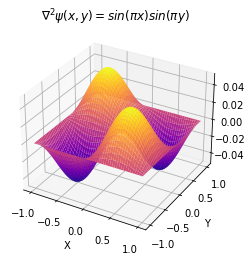

In [4]:
start = time.time()

nx ,ny , N = 100 , 100 , 8                                             #xy colocation dots
xx , yy = np.linspace(-1,1,nx) , np.linspace(-1,1,ny)                    #XY grid vectors
x,y=np.cos(np.arange(0,N+1,1)*np.pi/N),np.cos(np.arange(0,N+1,1)*np.pi/N)
b = np.zeros((N+1)**2)                                                   #Source vector
A = np.zeros(((N+1)**2, (N+1)**2))  
aa = np.zeros((N+1 , N+1))

for i in range(0,N+1):
    for j in range(0,N+1):
        for l in range(0,N+1):
            for k in range(0,N+1):
                if (i == 0) or (i==N) or (j==0) or (j==N):
                    A[i*(N+1)+j , l*(N+1)+k] = cheby(l,x[i])*cheby(k,y[j])
                else:
                    A[i*(N+1)+j , l*(N+1)+k] = f_int(l,k,x[i],y[j])

for i in range(0,N+1):
    for j in range(0,N+1):
        if (i == 0) or (i==N) or (j==0) or (j==N):
            b[i*(N+1)+j] = 0
        else:
            b[i*(N+1)+j] = f_source(x[i],y[j])

A_inv = np.linalg.inv(A)
X_sol = np.dot(A_inv,b)
mx , my = np.meshgrid(xx , yy)
for i in range(0,N):
    for j in range(0, N):
        aa[i,j] = X_sol[i*(N+1) +j]

Y = 0
for l in range(0,N+1):
    for k in range(0,N+1):
        Y += aa[l,k]*cheby(l,mx)*cheby(k,my)
end = time.time()
print('Time = ', end - start)

ax = plt.axes(projection = '3d')
ax.plot_surface(mx,my,Y, cmap = "plasma")
ax.set_title('$\\nabla^2\psi(x,y) = sin(\pi x)sin(\pi y)$')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()

## Galerkin's method

We're gonna develop this method to the time-independant case, so to generalize a bit, we're gonna solve the Helmholtz equation:

$\nabla^2 v(x,y) + \lambda^2 v(x,y) = f(x,y)$

As in the 1D case, we will approximate our solution function like this:

$v(x,y) \sum_{n,m =1}^N C_{nm}\phi_n(x)\phi_m(y)$

Thus, our PDE becomes:

$\sum_{n,m=1}^N\int_{a}^b\int_c^d\left[\frac{d^2 \phi_n(x)}{dx^2}\phi_i(x)\phi_m(y)\phi_j(y) + \phi_n(x)\phi_i(x)\frac{d^2\phi_m(y)}{dy^2}\phi_j(y) + \lambda^2 \phi_n(x)\phi_i(x)\phi_m(y)\phi_j(y) \right]dxdy\; C_{nm} = \int_a^b\int_c^df(x,y)\phi_i(x)\phi_j(y)dxdy$

Again, we've got a tensor: 

$\overleftrightarrow{T}= [T^{ij}_{nm}] = \int_{a}^b\int_c^d\left[\frac{d^2 \phi_n(x)}{dx^2}\phi_i(x)\phi_m(y)\phi_j(y) + \phi_n(x)\phi_i(x)\frac{d^2\phi_m(y)}{dy^2}\phi_j(y) + \lambda^2 \phi_n(x)\phi_i(x)\phi_m(y)\phi_j(y) \right]dxdy $

A coefficients matrix $\hat{C}$ and a source matrix:

$\hat{S} = [S^{ij}] = \int_a^b\int_c^df(x,y)\phi_i(x)\phi_j(y)dxdy$

Thus, the matrix $\hat{M}$ related to $\overleftrightarrow{T}$ is:

$\begin{bmatrix}
    T^{10}_{00} & T^{10}_{01} & ... & T^{10}_{0N} & T^{10}_{10}& ... &T^{10}_{1N} & ... & T^{1N}_{00} & ... & T^{1N}_{NN} \\
    T^{20}_{00} & T^{20}_{01} & ... & T^{20}_{0N} & T^{20}_{10}& ... &T^{20}_{1N} & ... & T^{2N}_{00} & ... & T^{2N}_{NN} \\
    ... & ... & ... & ... & ... & ... & ... & ... & ... & ... & ...\\
    T^{(N-1)0}_{00} & T^{(N-1)0}_{01} & ... & T^{(N-1)0}_{0N} & T^{(N-1)0}_{10}& ... &T^{(N-1)0}_{1N} & ... & T^{(N-1)N}_{00} & ... & T^{(N-1)N}_{NN} \\
    T^{N0}_{00} & T^{N0}_{01} & ... & T^{N0}_{0N} & T^{N0}_{10}& ... &T^{N0}_{1N} & ... & T^{NN}_{00} & ... & T^{NN}_{NN} 
\end{bmatrix}_{N^2xN^2}$

We must remember that the boundary conditions are implicit inside the scoring functions, thus our source vector is:

$C = \begin{bmatrix}
    S_{00}\\
    S_{01}\\
    S_{02}\\
    ...\\
    S_{NN}
\end{bmatrix}_{N^2}$

## Example 1 (With Galerkin): $\nabla^2 V(x,y) = sin(\pi x)sin(\pi y)$

with homogeneous Dirichlet boundary conditions such that:

$V(-1,y) = V(1,y) = V(x,-1) = V(x,1) = 0$

But, we must define new polynomials such that these fulfill the boundary conditions, so we're gonna use a combination of the Chebyshev's type 1 polynomials that we cal $\phi_n(x)$:

- If the order of the Chebyshev's polynomia is odd: $\phi_{2n-1}(x) = T_{2n-1}(x) - T_1(x)$
- If the order of the Chebyshev0s polynomia is even: $\phi_{2n}(x) = T_{2x}(x) - T_0(x)$
- The same for the functions on the Y-domain.

## Tau method